In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.3 MB/s eta 0:00:00


# Task
Implement a quantum reservoir computing approach using PennyLane to classify the IRIS dataset, including data preparation, defining the quantum encoding circuit and a trainable classical readout, training the combined model, and evaluating its performance.

## Load IRIS Dataset

### Subtask:
Load the IRIS dataset, preprocess it, and split it into training and testing sets. This will include preparing the data for angle embedding.

**Reasoning**:

I will import the necessary libraries, including `load_iris` for the dataset, `MinMaxScaler` for feature scaling, `OneHotEncoder` for label encoding, and `train_test_split` for splitting the data. Then I will load the IRIS dataset and assign it to a pandas DataFrame for better handling.

**In my opinion Pandas is not needed for IRIS, in general as a dataset it is quite easy to handle.**


In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Load the IRIS dataset
iris = load_iris()
X, y = iris.data, iris.target

# Convert to DataFrame for easier inspection (optional, but good practice)
df_features = pd.DataFrame(X, columns=iris.feature_names)
df_target = pd.DataFrame(y, columns=['species'])

print("IRIS dataset loaded successfully.")
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of features:\n", df_features.head())
print("First 5 rows of target:\n", df_target.head())

IRIS dataset loaded successfully.
Features (X) shape: (150, 4)
Target (y) shape: (150,)
First 5 rows of features:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
First 5 rows of target:
    species
0        0
1        0
2        0
3        0
4        0


**Reasoning**:
Now that the IRIS dataset is loaded, I will scale the features to a range suitable for angle embedding using `MinMaxScaler` and then scale them to `pi`. After that, I will convert the target labels to one-hot encoded vectors, which is a common requirement for classification models. Finally, I will split the preprocessed features and labels into training and testing sets.


In [2]:
import numpy as np

# Scale features for angle embedding (between 0 and pi)
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled * np.pi

print("Features scaled successfully (range 0 to pi).")
print("Min value of scaled features:", X_scaled.min())
print("Max value of scaled features:", X_scaled.max())
print("First 5 rows of scaled features:\n", X_scaled[:5])

# One-hot encode the target labels
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

print("Target labels one-hot encoded successfully.")
print("Shape of one-hot encoded labels:", y_onehot.shape)
print("First 5 rows of one-hot encoded labels:\n", y_onehot[:5])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y)

print("Dataset split into training and testing sets.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Features scaled successfully (range 0 to pi).
Min value of scaled features: 0.0
Max value of scaled features: 3.141592653589793
First 5 rows of scaled features:
 [[0.6981317  1.96349541 0.21298933 0.13089969]
 [0.52359878 1.30899694 0.21298933 0.13089969]
 [0.34906585 1.57079633 0.159742   0.13089969]
 [0.26179939 1.43989663 0.26623667 0.13089969]
 [0.61086524 2.0943951  0.21298933 0.13089969]]
Target labels one-hot encoded successfully.
Shape of one-hot encoded labels: (150, 3)
First 5 rows of one-hot encoded labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
Dataset split into training and testing sets.
X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120, 3)
y_test shape: (30, 3)


## Define Quantum Reservoir and Encoding Circuit

### Subtask:
Define the PennyLane quantum circuit for the 'frozen reservoir' and 'data encoding' using angle embedding. This circuit will act as the feature map for the input data.

**Reasoning**:

I will import the `pennylane` library, determine the number of qubits from the dataset's features, and create a PennyLane quantum device. Then, I will define the quantum function (`qnode`) that includes `qml.AngleEmbedding` for data encoding and a 'frozen reservoir' layer using fixed, randomly initialized `qml.CRX` and `qml.RX` gates. Finally, the circuit will return the expectation values of `qml.PauliZ` for each qubit.

In [4]:
import pennylane as qml
import numpy as np

# 2. Determine the number of qubits needed
num_features = X_train.shape[1] # The IRIS dataset has 4 features
num_qubits = num_features

# 3. Create a PennyLane quantum device
dev = qml.device('default.qubit', wires=num_qubits)

print(f"Number of features: {num_features}")
print(f"Number of qubits: {num_qubits}")
print("PennyLane device created successfully.")

# Define the number of layers for the frozen reservoir
reservoir_layers = 2

# Initialize fixed random parameters for the reservoir (e.g., for CRX and RX gates)
# These parameters should be fixed, not trainable
np.random.seed(42) # for reproducibility
reservoir_params_crx = np.random.uniform(0, 2 * np.pi, size=(reservoir_layers, num_qubits)).astype(np.float32)
reservoir_params_rx = np.random.uniform(0, 2 * np.pi, size=(reservoir_layers, num_qubits)).astype(np.float32)

@qml.qnode(dev)
def quantum_reservoir_circuit(inputs):
    # 5. Use qml.AngleEmbedding to encode the input features
    qml.AngleEmbedding(features=inputs, wires=range(num_qubits))

    # 6. Add a 'frozen reservoir' layer
    for layer in range(reservoir_layers):
        # Apply CRX gates between adjacent qubits
        for i in range(num_qubits):
            qml.CRX(reservoir_params_crx[layer, i], wires=[i, (i + 1) % num_qubits])
        # Apply RX gates to all qubits
        for i in range(num_qubits):
            qml.RX(reservoir_params_rx[layer, i], wires=i)

    # 7. For the output, return the expectation values of PauliZ observables for each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

print("Quantum reservoir circuit defined successfully.")

# Print a sample execution and draw the circuit for inspection
print("\nSample circuit execution with dummy inputs:")
dummy_inputs = np.array([0.1, 0.2, 0.3, 0.4]) * np.pi
output = quantum_reservoir_circuit(dummy_inputs)
print("Output for dummy inputs:", output)

print("\nCircuit drawing (first layer):")
print(qml.draw(quantum_reservoir_circuit)(dummy_inputs))

Number of features: 4
Number of qubits: 4
PennyLane device created successfully.
Quantum reservoir circuit defined successfully.

Sample circuit execution with dummy inputs:
Output for dummy inputs: [np.float64(-0.22564582886226542), np.float64(0.6557749591396806), np.float64(0.24061386184253952), np.float64(0.12364492443635766)]

Circuit drawing (first layer):
0: ─╭AngleEmbedding(M0)─╭●────────────────────────────╭RX(3.76)──RX(3.78)─╭●───────────────── ···
1: ─├AngleEmbedding(M0)─╰RX(2.35)─╭●──────────────────│──────────RX(4.45)─╰RX(0.98)─╭●─────── ···
2: ─├AngleEmbedding(M0)───────────╰RX(5.97)─╭●────────│──────────RX(0.13)───────────╰RX(0.98) ···
3: ─╰AngleEmbedding(M0)─────────────────────╰RX(4.60)─╰●─────────RX(6.09)──────────────────── ···

0: ··· ───────────╭RX(5.44)──RX(5.23)─┤  <Z>
1: ··· ───────────│──────────RX(1.33)─┤  <Z>
2: ··· ─╭●────────│──────────RX(1.14)─┤  <Z>
3: ··· ─╰RX(0.36)─╰●─────────RX(1.15)─┤  <Z>

M0 = 
[0.31415927 0.62831853 0.9424778  1.25663706]


## Implement Trainable Classical Readout

### Subtask:
Implement a classical neural network layer in PennyLane that will act as the 'trainable readout' after the quantum circuit. This layer will process the measurements from the quantum circuit.

**Reasoning**:
I will define the classical readout layer by first determining the input and output dimensions from the quantum circuit output and one-hot encoded labels, then initializing random weights and biases for a linear layer, and finally implementing a Python function `classical_readout_layer` to perform the linear transformation and output the logits.


Kiran wrote the code in TensorFlow, I am gonna convert it to Pytorch because I am not familiar to this package and also when the time comes to conversion to MerLin it will be easier because MerLin is written in PyTorch.



In [5]:
import tensorflow as tf
# Using TensorFlow for easier handling of classical layers and automatic differentiation

# 1. Determine the number of features output by the quantum circuit (num_qubits)
# This is already defined as num_qubits, which is 4.

# 2. Determine the number of output classes for the classical readout
num_output_classes = y_train.shape[1]

print(f"Number of qubits (quantum circuit output features): {num_qubits}")
print(f"Number of output classes: {num_output_classes}")

# 3. Initialize random weights and biases for a simple linear classical layer
# Using tf.Variable for trainable parameters, initialized randomly.
# Weights dimensions: (num_qubits, num_output_classes) for matmul with quantum_output_vector (batch_size, num_qubits)
# Biases dimensions: (num_output_classes,)

# Set a seed for reproducibility
tf.random.set_seed(42)

classical_weights = tf.Variable(
    tf.random.normal(shape=(num_qubits, num_output_classes), dtype=tf.float32),
    name='classical_weights'
)
classical_biases = tf.Variable(
    tf.zeros(shape=(num_output_classes,), dtype=tf.float32),
    name='classical_biases'
)

print("Classical weights and biases initialized successfully.")
print("classical_weights shape:", classical_weights.shape)
print("classical_biases shape:", classical_biases.shape)

# 4. Define a Python function `classical_readout_layer`
def classical_readout_layer(quantum_output, weights, biases):
    # Ensure quantum_output is a TensorFlow tensor for operations
    quantum_output_tensor = tf.cast(tf.constant(quantum_output), tf.float32)

    # 5. Perform a linear transformation: matrix multiply and add bias
    # The quantum_output will be a vector of expectation values (num_qubits,)
    # For a single sample, it's (num_qubits,)
    # We need to reshape it to (1, num_qubits) for matrix multiplication
    if len(quantum_output_tensor.shape) == 1:
        quantum_output_tensor = tf.expand_dims(quantum_output_tensor, axis=0) # Reshape to (1, num_qubits)

    # Matrix multiplication: (batch_size, num_qubits) @ (num_qubits, num_output_classes)
    # The result will be (batch_size, num_output_classes)
    logits = tf.matmul(quantum_output_tensor, weights) + biases

    # Squeeze if it was originally a single sample
    if tf.shape(logits)[0] == 1 and len(tf.shape(logits)) > 1:
        return tf.squeeze(logits, axis=0)
    return logits

print("Classical readout layer function 'classical_readout_layer' defined successfully.")

# Example usage:
# dummy_quantum_output = quantum_reservoir_circuit(dummy_inputs)
# dummy_logits = classical_readout_layer(dummy_quantum_output, classical_weights, classical_biases)
# print("\nDummy logits from classical readout layer:", dummy_logits)
# print("Dummy logits shape:", dummy_logits.shape)

Number of qubits (quantum circuit output features): 4
Number of output classes: 3
Classical weights and biases initialized successfully.
classical_weights shape: (4, 3)
classical_biases shape: (3,)
Classical readout layer function 'classical_readout_layer' defined successfully.


Quantum Reservoir (frozen)
        ↓
Torch Linear Layer (trainable)

In PyTorch


In [11]:
import torch
import torch.nn as nn

# Determine number of output classes properly
num_output_classes = len(torch.unique(y_train))

print(f"Number of qubits (quantum circuit output features): {num_qubits}")
print(f"Number of output classes: {num_output_classes}")

# Set seed
torch.manual_seed(42)

# Initialize trainable parameters
classical_weights = nn.Parameter(
    torch.randn(num_qubits, num_output_classes, dtype=torch.float32)
)

classical_biases = nn.Parameter(
    torch.zeros(num_output_classes, dtype=torch.float32)
)

print("Classical weights and biases initialized successfully.")
print("classical_weights shape:", classical_weights.shape)
print("classical_biases shape:", classical_biases.shape)


def classical_readout_layer(quantum_output, weights, biases):

    quantum_output_tensor = torch.tensor(
        quantum_output, dtype=torch.float32
    )

    if quantum_output_tensor.dim() == 1:
        quantum_output_tensor = quantum_output_tensor.unsqueeze(0)

    logits = quantum_output_tensor @ weights + biases

    if logits.shape[0] == 1:
        logits = logits.squeeze(0)

    return logits


print("Classical readout layer defined successfully.")

Number of qubits (quantum circuit output features): 4
Number of output classes: 3
Classical weights and biases initialized successfully.
classical_weights shape: torch.Size([4, 3])
classical_biases shape: torch.Size([3])
Classical readout layer defined successfully.


## Build and Train PennyLane Model

### Subtask:
Combine the quantum circuit and the classical readout layer into a complete PennyLane model. Train this model on the prepared IRIS dataset, measuring on Pauli Z, and optimize the trainable classical parameters.


**Reasoning**:
I will first define the `hybrid_model` function that combines the quantum reservoir circuit and the classical readout layer. Then, I will define a cross-entropy loss function, instantiate a TensorFlow Adam optimizer, and finally implement the training loop to train the classical readout layer using `tf.GradientTape` for automatic differentiation.



**TensorFlow Version From Kiran**


In [11]:
import tensorflow as tf

# 1. Define a function `hybrid_model` that combines the quantum circuit and classical readout
def hybrid_model(inputs, weights, biases):
    # Get output from the quantum reservoir circuit
    quantum_output = quantum_reservoir_circuit(inputs)
    # Pass quantum output to the classical readout layer
    logits = classical_readout_layer(quantum_output, weights, biases)
    return logits

# 2. Define a cross-entropy loss function
def cross_entropy_loss(logits, true_labels):
    # Ensure true_labels are float32 for compatibility with logits
    true_labels_float = tf.cast(true_labels, tf.float32)
    loss = tf.nn.softmax_cross_entropy_with_logits(labels=true_labels_float, logits=logits)
    return tf.reduce_mean(loss)

# 3. Instantiate a TensorFlow optimizer
learning_rate = 0.01
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

print("Hybrid model, loss function, and optimizer defined successfully.")

# 4. Implement the training loop
epochs = 30 # Number of training epochs
batch_size = 8 # Size of mini-batches

# Convert numpy arrays to TensorFlow datasets for easier batching
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(batch_size)

print(f"\nStarting training for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_dataset:
        with tf.GradientTape() as tape:
            # Ensure classical_weights and classical_biases are watched by the tape
            tape.watch([classical_weights, classical_biases])

            # Get predictions from the hybrid model
            logits = hybrid_model(batch_X, classical_weights, classical_biases)

            # Calculate the loss
            loss = cross_entropy_loss(logits, batch_y)

        # Compute gradients
        gradients = tape.gradient(loss, [classical_weights, classical_biases])

        # Apply gradients to update classical parameters
        optimizer.apply_gradients(zip(gradients, [classical_weights, classical_biases]))

        epoch_loss += loss.numpy()

    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / len(train_dataset)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

print("\nTraining complete.")

**PyTorch Version from Ayana**

In [14]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------------
# 1. Hybrid model function
# -----------------------------------

def hybrid_model(inputs, weights, biases):
    batch_outputs = []

    for sample in inputs:
        quantum_output = quantum_reservoir_circuit(sample)
        quantum_output = torch.stack(quantum_output).float()
        batch_outputs.append(quantum_output)

    quantum_batch = torch.stack(batch_outputs)

    logits = quantum_batch @ weights + biases
    return logits


# -----------------------------------
# 2. Loss function
# -----------------------------------

def cross_entropy_loss(logits, true_labels):
    return F.cross_entropy(logits, true_labels)


# -----------------------------------
# 3. Optimizer
# -----------------------------------

learning_rate = 0.01
optimizer = torch.optim.Adam([classical_weights, classical_biases], lr=learning_rate)

print("Hybrid model, loss function, and optimizer defined successfully.")


# -----------------------------------
# 4. Training loop
# -----------------------------------

epochs = 50
batch_size = 8

# Create PyTorch dataset and loader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"\nStarting training for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        logits = hybrid_model(batch_X, classical_weights, classical_biases)

        loss = cross_entropy_loss(logits, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

print("\nTraining complete.")

Hybrid model, loss function, and optimizer defined successfully.

Starting training for 50 epochs...


/tmp/ipython-input-183/1773220115.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-183/1773220115.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.long)


Epoch 1/50, Loss: 0.5639
Epoch 5/50, Loss: 0.5172
Epoch 10/50, Loss: 0.4828
Epoch 15/50, Loss: 0.4573
Epoch 20/50, Loss: 0.4388
Epoch 25/50, Loss: 0.4260
Epoch 30/50, Loss: 0.4125
Epoch 35/50, Loss: 0.4026
Epoch 40/50, Loss: 0.3948
Epoch 45/50, Loss: 0.3879
Epoch 50/50, Loss: 0.3805

Training complete.


**Visualization**

In [16]:
# Use only first two features for visualization
X2 = X[:, :2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize again
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

# Map to (0, π)
X2_train = 1 / (1 + np.exp(-X2_train)) * np.pi
X2_test  = 1 / (1 + np.exp(-X2_test)) * np.pi

X2_train = torch.tensor(X2_train, dtype=torch.float32)
X2_test  = torch.tensor(X2_test, dtype=torch.float32)

y2_train = torch.tensor(y2_train, dtype=torch.long)
y2_test  = torch.tensor(y2_test, dtype=torch.long)

**Reasoning**:
The training loop has completed successfully, and the model has been trained. The next logical step is to evaluate the model's performance on the unseen test dataset. This involves making predictions using the trained hybrid model, converting these predictions into class labels, and comparing them with the true labels to calculate accuracy.

**Test training with TensorFlow - Kiran's Code**

In [ ]:
import numpy as np
import tensorflow as tf

# Make predictions on the test set
def predict(X, weights, biases):
    logits = hybrid_model(X, weights, biases)
    # Apply softmax to get probabilities, then argmax to get predicted class
    probabilities = tf.nn.softmax(logits)
    predicted_labels = tf.argmax(probabilities, axis=1)
    return predicted_labels

# Get predictions for the test set
predictions = predict(X_test, classical_weights, classical_biases)

# Convert one-hot encoded y_test to class labels
true_labels = tf.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = np.mean(predictions.numpy() == true_labels.numpy())

print(f"Model accuracy on the test set: {accuracy:.4f}")

# Display some sample predictions vs true labels
print("\nSample predictions vs true labels (first 10 samples):")
for i in range(10):
    print(f"Sample {i+1}: Predicted: {predictions.numpy()[i]}, True: {true_labels.numpy()[i]}")

My PyTorch Code - Ayana

In [15]:
import torch
import torch.nn.functional as F

# 1. Prediction function
def predict(X, weights, biases):
    with torch.no_grad():
        logits = hybrid_model(X, weights, biases)
        probabilities = F.softmax(logits, dim=1)
        predicted_labels = torch.argmax(probabilities, dim=1)
    return predicted_labels


# 2. Get predictions
predictions = predict(X_test, classical_weights, classical_biases)

# 3. True labels (already class indices in PyTorch version)
true_labels = y_test

# 4. Calculate accuracy
accuracy = (predictions == true_labels).float().mean().item()

print(f"Model accuracy on the test set: {accuracy:.4f}")

# 5. Display some sample predictions vs true labels
print("\nSample predictions vs true labels (first 10 samples):")
for i in range(10):
    print(f"Sample {i+1}: Predicted: {predictions[i].item()}, True: {true_labels[i].item()}")

Model accuracy on the test set: 0.7000

Sample predictions vs true labels (first 10 samples):
Sample 1: Predicted: 0, True: 0
Sample 2: Predicted: 2, True: 2
Sample 3: Predicted: 1, True: 1
Sample 4: Predicted: 1, True: 1
Sample 5: Predicted: 0, True: 0
Sample 6: Predicted: 2, True: 1
Sample 7: Predicted: 0, True: 0
Sample 8: Predicted: 0, True: 0
Sample 9: Predicted: 2, True: 2
Sample 10: Predicted: 1, True: 1


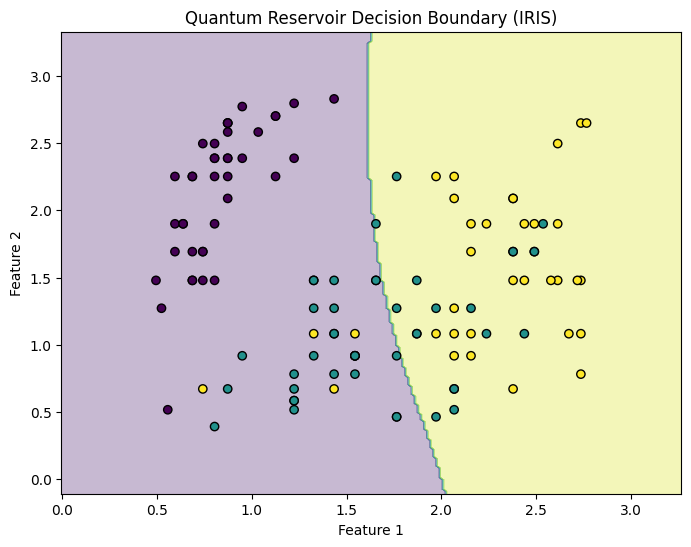

In [17]:
import matplotlib.pyplot as plt

# Create mesh grid
x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict over grid
with torch.no_grad():
    logits = hybrid_model(grid_tensor, classical_weights, classical_biases)
    Z = torch.argmax(logits, dim=1).numpy()

Z = Z.reshape(xx.shape)

# Plot contour
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)

# Plot training points
plt.scatter(
    X2_train[:, 0],
    X2_train[:, 1],
    c=y2_train.numpy(),
    edgecolor='k',
    cmap=plt.cm.viridis
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Quantum Reservoir Decision Boundary (IRIS)")
plt.show()

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

# Ensure true_labels and predictions are in the correct format (1D arrays of class indices)
# true_labels is already a 1D array of class indices from the previous step
# predictions is already a 1D array of class indices from the previous step

# Convert TensorFlow tensors to NumPy arrays if they haven't been already
true_labels_np = true_labels.numpy()
predictions_np = predictions.numpy()

print("\n--- Classification Report ---")
print(classification_report(true_labels_np, predictions_np))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(true_labels_np, predictions_np))


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.67      0.40      0.50        10
           2       0.56      0.90      0.69        10

    accuracy                           0.70        30
   macro avg       0.74      0.70      0.69        30
weighted avg       0.74      0.70      0.69        30


--- Confusion Matrix ---
[[8 1 1]
 [0 4 6]
 [0 1 9]]
